# Гибрид: LLM-разметка, NER поверх словарей, честное сравнение

Продолжение [01_eda_rule_based.ipynb](01_eda_rule_based.ipynb).

Идея: rule-based экстрактор остаётся первым слоем — он быстрый, точный и
объяснимый. На запросах, где он молчит, подключается компактная NER-модель
(энкодер, не генеративная LLM). LLM используется только для разметки обучающих
данных, как разрешает условие задания.

Что проверяем: даёт ли такой гибрид прирост над одними словарями, и если нет —
почему.

**Короткий ответ:** гибрид помогает ровно там, где задумывался, и вредит везде
остальном. На длинном хвосте F1 по категории растёт с 0.464 до 0.530, на
случайной выборке падает с 0.928 до 0.763. Разбор — в конце ноутбука.

## Данные и rule-based слой


In [1]:
import json
import re
import sys

import numpy as np
import pandas as pd
import torch

sys.path.append("..")

from src.extractor import extract_all
from src.bio import (
    ATTRS, LABEL_LIST, LABEL2ID, ID2LABEL, TAG_TO_ATTR,
    rule_based_to_bio, bio_to_attr_dict, canonize, clean_subword,
)
from src.metrics import score_extraction, metrics_table

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

df = pd.read_csv("../data/test_queries_sample.csv")
df["query_norm"] = df["query_text"].apply(
    lambda t: re.sub(r"\s+", " ", str(t).lower().replace("ё", "е")).strip()
)

extraction = pd.json_normalize(df["query_norm"].apply(extract_all))
df = pd.concat([df.reset_index(drop=True), extraction.reset_index(drop=True)], axis=1)

covered = df[ATTRS].notna().any(axis=1)
print(f"Rule-based покрыл: {covered.mean():.1%}")
print(f"Не покрыл: {(~covered).sum()} запросов")

Rule-based покрыл: 45.6%
Не покрыл: 10885 запросов

## Отбор запросов для разметки

Размечать весь датасет через LLM дорого и избыточно там, где словари уже дают
надёжный ответ. Беру только непокрытые запросы — именно они несут сигнал,
которого в словарях нет. Дополнительно отсекаю совсем короткий шум (1-2 символа,
голые числа): размечать его бессмысленно.


In [2]:
def is_noisy(text: str) -> bool:
    return len(text) <= 2 or bool(re.fullmatch(r"\d+", text))


uncovered = df.loc[~covered & ~df["query_norm"].apply(is_noisy)]
print(f"Кандидатов после фильтрации шума: {len(uncovered)}")

LABELING_SAMPLE_SIZE = 800
labeling_sample = uncovered.sample(
    n=min(LABELING_SAMPLE_SIZE, len(uncovered)), random_state=RANDOM_STATE
)["query_norm"].tolist()

print(f"Отобрано на разметку: {len(labeling_sample)}")
labeling_sample[:8]

Кандидатов после фильтрации шума: 10879
Отобрано на разметку: 800

['посуда для пикника',
 'инкубатор ово на 156 яиц',
 'муляж купольной камеры',
 'тарелка пасхальная для яиц и кулича с зайцем',
 'kicker динамики',
 'картины по номерам античность',
 'nan 3 гипоаллергенный',
 'вейв']

Почему 800, а не 150 и не 5000. Энкодер на BIO-тегах требует меньше данных,
чем кажется: для пяти типов сущностей на русском 500-1000 качественно
размеченных примеров дают рабочую модель. Меньше — не хватит на обобщение за
пределы частых паттернов, больше — расходы на API растут линейно, а качество на
первой итерации нет. Стоит ли доразмечивать, видно уже после первого цикла
обучения.


## Разметка через LLM

Разметка выполнена отдельным прогоном через Groq API (`llama-3.1-8b-instant`),
результат лежит в `data/llm_labels_raw.json`. Здесь файл загружается — повторная
разметка тех же 800 запросов не изменит результат.

Формат — сразу BIO-теги по токенам, а не «извлеки атрибуты» свободным текстом.
Это даёт согласованный формат, который без дополнительного парсинга ложится в
обучение sequence labeling.


In [3]:
LABELING_SYSTEM_PROMPT = """Ты размечаешь поисковые запросы маркетплейса для обучения NER-модели.
Для каждого запроса верни JSON со списком токенов и BIO-тегом для каждого:
теги: O, B-BRAND, I-BRAND, B-CATEGORY, I-CATEGORY, B-COLOR, I-COLOR, B-GENDER, I-GENDER, B-SIZE, I-SIZE

Правила:
- Токенизация по пробелам, знаки препинания — отдельные токены.
- BRAND — название бренда/производителя (включая транслит и опечатки).
- CATEGORY — тип товара (существительное, обозначающее сам товар).
- COLOR — цвет.
- GENDER — пол/возрастная группа (мужской/женский/детский/унисекс).
- SIZE — размер (число, буквенный размер, "большой"/"маленький").
- Если сомневаешься — ставь O, не угадывай.

Верни ТОЛЬКО JSON вида {"tokens": [...], "tags": [...]}, без пояснений."""


def parse_llm_labels(raw_response: str, query: str):
    """
    Парсит ответ модели в {tokens, tags} с проверкой формата.

    Возвращает None, если ответ не распарсился или не прошёл проверки. Такие
    случаи отбрасываются, а не чинятся догадками: иначе в обучающую выборку
    попадёт шум от парсинга, который потом не отличить от шума разметки.
    """
    try:
        parsed = json.loads(raw_response.strip())
    except json.JSONDecodeError:
        return None

    tokens, tags = parsed.get("tokens"), parsed.get("tags")
    if not tokens or not tags or len(tokens) != len(tags):
        return None
    if not all(t in LABEL_LIST for t in tags):
        return None
    if "".join(tokens).replace(" ", "") != query.replace(" ", ""):
        return None

    return {"query": query, "tokens": tokens, "tags": tags}

In [4]:
import time
import requests

RUN_LABELING = False  # разметка выполнена заранее, результат в data/llm_labels_raw.json


def call_groq(query: str, api_key: str, max_retries: int = 3):
    url = "https://api.groq.com/openai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    payload = {
        "model": "llama-3.1-8b-instant",
        "messages": [
            {"role": "system", "content": LABELING_SYSTEM_PROMPT},
            {"role": "user", "content": f"Запрос: {query}"},
        ],
        "temperature": 0,
        "max_tokens": 500,
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(url, headers=headers, json=payload, timeout=30)
            r.raise_for_status()
            return parse_llm_labels(r.json()["choices"][0]["message"]["content"], query)
        except Exception:
            if attempt == max_retries - 1:
                return None
            time.sleep(2 ** attempt)
    return None


if RUN_LABELING:
    from kaggle_secrets import UserSecretsClient
    api_key = UserSecretsClient().get_secret("key")

    llm_labels = [r for r in (call_groq(q, api_key) for q in labeling_sample) if r is not None]
    with open("../data/llm_labels_raw.json", "w", encoding="utf-8") as f:
        json.dump(llm_labels, f, ensure_ascii=False)
else:
    with open("../data/llm_labels_raw.json", encoding="utf-8") as f:
        llm_labels = json.load(f)

n_ok = len(llm_labels)
print(f"Размечено успешно: {n_ok} из {LABELING_SAMPLE_SIZE} ({n_ok / LABELING_SAMPLE_SIZE:.1%})")
print(f"Не прошли проверку формата: {LABELING_SAMPLE_SIZE - n_ok}")
llm_labels[:2]

Размечено успешно: 694 из 800 (86.8%)
Не прошли проверку формата: 106

[{'query': 'посуда для пикника',
  'tokens': ['посуда', 'для', 'пикника'],
  'tags': ['O', 'O', 'B-CATEGORY']},
 {'query': 'инкубатор ово на 156 яиц',
  'tokens': ['инкубатор', 'ово', 'на', '156', 'яиц'],
  'tags': ['O', 'O', 'O', 'O', 'O']}]

## Проверка разметки

Сверяю разметку LLM с rule-based на пересечении. Ожидаемо расхождений будет
много: выборка отбиралась как раз из того, что словари не покрыли, и «LLM нашла
атрибут там, где словарь молчит» — это ровно то, ради чего затевался гибрид.

Признаком проблемы было бы обратное: словарь уверенно находит значение, а LLM
ставит на этом месте `O`. Такие случаи считаю отдельно — они означают, что
разметке нельзя доверять.


In [5]:
disagreements = {"llm_found_rb_silent": 0, "rb_found_llm_silent": 0, "different_value": 0}
suspicious = []

for row in llm_labels:
    query = " ".join(row["tokens"])
    rb = extract_all(query)
    llm = bio_to_attr_dict(row["tokens"], row["tags"])

    for attr in ("brand", "category", "color", "gender"):
        rb_value, llm_value = rb.get(attr), llm.get(attr)
        if rb_value is None and llm_value is not None:
            disagreements["llm_found_rb_silent"] += 1
        elif rb_value is not None and llm_value is None:
            disagreements["rb_found_llm_silent"] += 1
            suspicious.append((query, attr, rb_value))
        elif rb_value is not None and llm_value is not None and rb_value != llm_value:
            disagreements["different_value"] += 1
            suspicious.append((query, attr, f"{rb_value} / {llm_value}"))

print(pd.Series(disagreements).to_string())
print()
print("Примеры, где словарь нашёл, а LLM пропустила или ответила иначе:")
for row in suspicious[:10]:
    print(" ", row)

llm_found_rb_silent    521
rb_found_llm_silent      1
different_value          0
Примеры, где словарь нашёл, а LLM пропустила или ответила иначе:
  ('диван 24', 'category', 'диван')

Разметка проходит проверку хорошо: 521 случай «LLM нашла там, где словарь
молчит» — это ровно то, ради чего затевался гибрид, а обратных случаев,
которые указывали бы на плохую разметку, всего один (`диван 24`, где LLM
пропустила категорию). Расхождений по значению нет вовсе.

То есть там, где словари и LLM пересекаются, они согласны. Это не гарантирует
качества разметки на хвосте, где сверять не с чем, но снимает подозрение, что
модель размечает наугад.


## Обучающая выборка

Два источника BIO-разметки:

1. **LLM** — запросы из длинного хвоста, которых нет в словарях. Это ценный
   сигнал, но его мало.
2. **Rule-based** — разметка, полученная напрямую из словарных совпадений на
   покрытых запросах. Практически бесплатная и её можно получить сколько угодно.

Здесь важен состав. В первой версии я взял 3000 rule-based примеров на 694 от
LLM. Результат предсказуемый: модель выучила словарь, то есть ровно то, что
первый слой и так умеет, и не получила достаточного сигнала на хвосте — а
проверяется она именно на хвосте.

Поэтому rule-based примеров беру примерно столько же, сколько LLM-примеров.
Полностью отказываться от них не стоит: они дают модели покрытие частых
паттернов и стабилизируют обучение, — но доминировать в выборке они не должны.


In [6]:
import random
random.seed(RANDOM_STATE)

rb_pool = df.loc[covered, "query_norm"].tolist()
random.shuffle(rb_pool)

RB_RATIO = 1.0  # сколько rule-based примеров на один LLM-пример
rb_examples = []
for query in rb_pool:
    row = rule_based_to_bio(query)
    if row is None or all(t == "O" for t in row["tags"]):
        continue
    rb_examples.append({"query": query, **row})
    if len(rb_examples) >= int(len(llm_labels) * RB_RATIO):
        break

all_examples = llm_labels + rb_examples
random.shuffle(all_examples)

split = int(0.9 * len(all_examples))
train_examples, eval_examples = all_examples[:split], all_examples[split:]

print(f"LLM-примеров:        {len(llm_labels)}")
print(f"Rule-based примеров: {len(rb_examples)}")
print(f"train / eval:        {len(train_examples)} / {len(eval_examples)}")

tag_counts = pd.Series([t for ex in train_examples for t in ex["tags"]]).value_counts()
print()
print(tag_counts.to_string())

LLM-примеров:        694
Rule-based примеров: 694
train / eval:        1249 / 139
O             3219
B-CATEGORY     779
B-BRAND        250
B-GENDER       184
I-CATEGORY     135
B-COLOR        112
I-BRAND         63
I-GENDER        56
B-SIZE          47
I-SIZE          18
I-COLOR          5

Распределение тегов сильно перекошено в сторону `O` — это нормально для NER,
но означает, что token-level accuracy как метрика бесполезна. Оценивать буду
entity-level F1 через `seqeval`: частичное совпадение спана не засчитывается.


Про два eval-набора. `eval_examples` выше — технический контроль обучения
(ранняя остановка, выбор лучшего чекпоинта), он из того же распределения, что и
train. Итоговое сравнение подходов идёт на других данных, которые модель не
видела вообще, — см. раздел ниже. Смешивать их нельзя: `eval_examples` содержит
паттерны, близкие к обучающим, и завышает впечатление о качестве.


## Обучение NER

`rubert-tiny2` — компактный русский энкодер (29 млн параметров). Выбран из-за
размера: на инференсе он добавляет к словарному слою миллисекунды, а не десятки
миллисекунд, что важно для поиска.

Про гиперпараметры. В первой версии обучение шло 8 эпох с `lr=3e-5` и
заканчивалось с training loss около 1.5 — то есть не сходилось. Для модели
такого размера `3e-5` мал: это значение из рецептов для BERT-base, у которого
на два порядка больше параметров и куда более выраженные предобученные
представления. Поднимаю до `2e-4`, добавляю warmup и довожу до 20 эпох с ранней
остановкой по F1.


In [7]:
!pip install -q --use-pep517 seqeval

In [8]:
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)
from datasets import Dataset
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

MODEL_NAME = "cointegrated/rubert-tiny2"

print("CUDA:", torch.cuda.is_available())
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_and_align(example):
    """
    Выравнивает BIO-метки уровня слова на subword-токены.

    Спецтокены получают -100 и не участвуют в лоссе. Продолжение слова получает
    I-тег вместо повторного B-, иначе одна сущность превратится в несколько.
    """
    tokenized = tokenizer(example["tokens"], truncation=True, is_split_into_words=True)
    label_ids, previous = [], None

    for word_id in tokenized.word_ids():
        if word_id is None:
            label_ids.append(-100)
        elif word_id != previous:
            label_ids.append(LABEL2ID[example["tags"][word_id]])
        else:
            tag = example["tags"][word_id]
            label_ids.append(LABEL2ID[tag.replace("B-", "I-")] if tag != "O" else LABEL2ID["O"])
        previous = word_id

    tokenized["labels"] = label_ids
    return tokenized


train_dataset = Dataset.from_list(train_examples).map(
    tokenize_and_align, remove_columns=["query", "tokens", "tags"])
eval_dataset = Dataset.from_list(eval_examples).map(
    tokenize_and_align, remove_columns=["query", "tokens", "tags"])

print(len(train_dataset), len(eval_dataset))

CUDA: True

1249 139

In [9]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[ID2LABEL[l] for l in label if l != -100] for label in labels]
    true_preds = [
        [ID2LABEL[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]
    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds),
    }


model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABEL_LIST), id2label=ID2LABEL, label2id=LABEL2ID,
)

training_args = TrainingArguments(
    output_dir="ner_checkpoints",
    learning_rate=2e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=20,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    seed=RANDOM_STATE,
    report_to="none",
    logging_steps=20,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
)

trainer.train()

Key                                        | Status     | 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,1.324750,1.164868,0.000000,0.000000,0.000000
2,0.891171,0.823997,0.362832,0.267974,0.308271
3,0.673773,0.739651,0.402367,0.444444,0.422360
4,0.493099,0.803089,0.455882,0.607843,0.521008
5,0.280142,1.000953,0.448780,0.601307,0.513966
6,0.181553,1.036994,0.475248,0.627451,0.540845
7,0.134424,1.085801,0.511111,0.601307,0.552553
8,0.103942,1.264280,0.423423,0.614379,0.501333
9,0.072558,1.306913,0.466981,0.647059,0.542466
10,0.050210,1.321887,0.460094,0.640523,0.535519


TrainOutput(global_step=440, training_loss=0.44252992340109565, metrics={'train_runtime': 36.9803, 'train_samples_per_second': 675.496, 'train_steps_per_second': 21.633, 'total_flos': 2989852939392.0, 'train_loss': 0.44252992340109565, 'epoch': 11.0})

In [10]:
trainer.save_model("ner_model_final")
tokenizer.save_pretrained("ner_model_final")

print(trainer.evaluate())

# отчёт по типам сущностей на техническом eval
predictions, labels, _ = trainer.predict(eval_dataset)
predictions = np.argmax(predictions, axis=2)
true_labels = [[ID2LABEL[l] for l in label if l != -100] for label in labels]
true_preds = [[ID2LABEL[p] for p, l in zip(pred, label) if l != -100]
              for pred, label in zip(predictions, labels)]
print(classification_report(true_labels, true_preds))

Training Loss,Validation Loss,Epoch,Precision,Recall,F1
0.038807,1.085801,11,0.511111,0.601307,0.552553


{'eval_loss': 1.0858005285263062, 'eval_precision': 0.5111111111111111, 'eval_recall': 0.6013071895424836, 'eval_f1': 0.5525525525525525}

              precision    recall  f1-score   support
       BRAND       0.28      0.34      0.31        32
    CATEGORY       0.51      0.65      0.57        80
       COLOR       0.64      0.88      0.74         8
      GENDER       0.84      0.81      0.82        26
        SIZE       0.33      0.14      0.20         7
   micro avg       0.51      0.60      0.55       153
   macro avg       0.52      0.56      0.53       153
weighted avg       0.52      0.60      0.55       153

Entity-level F1 на техническом eval — 0.55. По типам сущностей картина
неравномерная: GENDER 0.82 и COLOR 0.74 (закрытые словари из нескольких
десятков значений, модель их выучивает), CATEGORY 0.57, BRAND 0.31, SIZE 0.20.

Это ожидаемая иерархия. Пол и цвет — конечные множества, их можно выучить с
700 примеров. Категории и бренды — открытые множества с длинным хвостом, где
каждое значение встречается в обучении один-два раза. SIZE вдобавок сам по себе
неоднозначен (см. разбор ниже).


## Инференс NER и гибрид

Два момента, из-за которых первая версия сравнения была некорректной.

**Артефакты subword-токенизатора.** Пайплайн возвращает фрагменты вида
`кроссов ##ки`; их нужно склеить, иначе значение не совпадёт ни с чем.

**Канонизация.** Модель возвращает фрагмент исходного текста («белая», «штиль»),
а словари и ручная разметка оперируют канонами («белый», «stihl»). Если
канонизировать только разметку, а предсказание сравнивать как есть, модель
получает ошибку за форму слова, а не за промах. Rule-based при этом не
штрафуется, потому что сам возвращает каноны — и сравнение подходов
разваливается. Канонизация применяется к обеим сторонам одной функцией.


In [11]:
from transformers import pipeline

ner_pipeline = pipeline(
    "token-classification",
    model="ner_model_final",
    tokenizer=tokenizer,
    aggregation_strategy="first",
    device=0 if torch.cuda.is_available() else -1,
)

CONFIDENCE_THRESHOLD = 0.5


def ner_extract(query: str, threshold: float = CONFIDENCE_THRESHOLD) -> dict:
    result = {a: None for a in ATTRS}
    for entity in ner_pipeline(query):
        attr = TAG_TO_ATTR.get(entity["entity_group"])
        if attr and result[attr] is None and entity["score"] >= threshold:
            result[attr] = canonize(attr, clean_subword(entity["word"]))
    return result


def hybrid_extract(query: str, threshold: float = CONFIDENCE_THRESHOLD) -> dict:
    """Словари — база. NER заполняет только то, что словари не нашли."""
    result = {a: canonize(a, v) for a, v in extract_all(query).items() if a in ATTRS}
    for entity in ner_pipeline(query):
        attr = TAG_TO_ATTR.get(entity["entity_group"])
        if attr and result.get(attr) is None and entity["score"] >= threshold:
            result[attr] = canonize(attr, clean_subword(entity["word"]))
    return result


for q in ("nike кроссовки черные", "аккумулятор для пылесоса dyson sv11", "агроткань черная 3 метра"):
    print(f"{q!r}")
    print("  rule-based:", {k: v for k, v in extract_all(q).items() if k in ATTRS})
    print("  ner:       ", ner_extract(q))
    print("  гибрид:    ", hybrid_extract(q))

'nike кроссовки черные'
  rule-based: {'brand': 'nike', 'category': 'кроссовки', 'color': 'черный', 'gender': None, 'size': None}
  ner:        {'brand': 'nike', 'category': 'кроссовки', 'color': 'черный', 'gender': None, 'size': None}
  гибрид:     {'brand': 'nike', 'category': 'кроссовки', 'color': 'черный', 'gender': None, 'size': None}
'аккумулятор для пылесоса dyson sv11'
  rule-based: {'brand': 'dyson', 'category': 'аккумулятор', 'color': None, 'gender': None, 'size': None}
  ner:        {'brand': None, 'category': 'пылесос', 'color': None, 'gender': None, 'size': None}
  гибрид:     {'brand': 'dyson', 'category': 'аккумулятор', 'color': None, 'gender': None, 'size': None}
'агроткань черная 3 метра'
  rule-based: {'brand': None, 'category': None, 'color': 'черный', 'gender': None, 'size': None}
  ner:        {'brand': None, 'category': 'агроткань', 'color': 'черный', 'gender': None, 'size': None}
  гибрид:     {'brand': None, 'category': 'агроткань', 'color': 'черный', 'gender': 

## Сравнение на двух выборках

Одна выборка здесь не годится, и это важный момент.

Выборка из 100 запросов, размеченная для этого сравнения, собрана из
**непокрытых** rule-based запросов — то есть из длинного хвоста. На ней словари
по построению выглядят хуже, чем они есть: в неё намеренно попало то, чего в них
нет. Это правильная выборка для вопроса «закрывает ли NER пробелы словарей», но
неправильная для вопроса «какой подход лучше вообще».

Поэтому считаю на обеих: на хвосте и на случайных 150 запросах из первого
ноутбука.


### Отдельно про SIZE: разметка и экстрактор понимают его по-разному

При сверке выяснилось, что расхождение по этому атрибуту — не ошибка модели,
а разное определение сущности.

В ручной BIO-разметке размером помечено всё, что описывает габарит: «50 см»,
«160x200», «64 гб», «4 метра». Экстрактор из первого ноутбука считает размером
только позицию размерной сетки («42», «XL», «большой»), а числа с единицей
измерения кладёт в отдельный атрибут `values_with_unit` — это было осознанное
решение, потому что диагональ телевизора и размер обуви это разные вещи.

Из 16 размеров в разметке 5 — это «число + единица», ещё несколько — габариты
вида «160x200», которых экстрактор не разбирает вовсе. Сравнивать подходы по
такому атрибуту нельзя: расходятся не предсказания, а инструкции.

Поэтому дальше сравнение считается по четырём атрибутам с согласованным
определением, а SIZE разбирается отдельно. Правильное решение на будущее —
переписать инструкцию по разметке и переразметить, а не подгонять код под
несовпадающую разметку.


In [12]:
import re

from data.ner_ground_truth import NEW_VAL_GROUND_TRUTH

UNIT_RE = re.compile(r"\d+\s*(см|мм|кг|г|л|мл|шт|дюйм|вт|гб|метр)")

gt_sizes = [bio_to_attr_dict(r["tokens"], r["tags"])["size"] for r in NEW_VAL_GROUND_TRUTH]
gt_sizes = [s for s in gt_sizes if s]

with_unit = [s for s in gt_sizes if UNIT_RE.search(s)]
dimensions = [s for s in gt_sizes if re.fullmatch(r"\d+\s*[x×\s]\s*\d+", s)]

print(f"Размеров в ручной разметке: {len(gt_sizes)}")
print(f"  из них 'число + единица' (у экстрактора это values_with_unit): {len(with_unit)} -> {with_unit}")
print(f"  габариты вида 160x200 (экстрактор не разбирает):              {len(dimensions)} -> {dimensions}")

COMPARABLE = ["brand", "category", "color", "gender"]

Размеров в ручной разметке: 16
  из них 'число + единица' (у экстрактора это values_with_unit): 5 -> ['50 см', '4 метра', '7 дюймов', '75 см', '64 гб']
  габариты вида 160x200 (экстрактор не разбирает):              4 -> ['160x200', '140 205', '160x190', '80 190']

In [13]:
from data.ner_ground_truth import NEW_VAL_GROUND_TRUTH
from data.ground_truth_attrs import GROUND_TRUTH

# выборка 1: длинный хвост (то, что словари не покрыли)
tail_queries = [row["query"] for row in NEW_VAL_GROUND_TRUTH]
tail_truth = [bio_to_attr_dict(row["tokens"], row["tags"]) for row in NEW_VAL_GROUND_TRUTH]

# выборка 2: случайные запросы из всего датасета
random_sample = df.sample(150, random_state=100).reset_index(drop=True)
random_queries = random_sample["query_norm"].tolist()
random_truth = [GROUND_TRUTH[i] for i in range(len(random_queries))]

APPROACHES = {
    "rule-based": lambda q: {k: v for k, v in extract_all(q).items() if k in ATTRS},
    "NER": ner_extract,
    "гибрид": hybrid_extract,
}

COMPARABLE = ["brand", "category", "color", "gender"]

def compare(queries, truth, title):
    frames = {}
    for name, fn in APPROACHES.items():
        preds = [fn(q) for q in queries]
        counts, _ = score_extraction(queries, preds, truth)
        table = metrics_table(counts, truth).set_index("attribute")
        frames[name] = table.loc[COMPARABLE, "f1"]

    table = pd.DataFrame(frames)
    print(title)
    print(table.round(3).to_string())
    print()
    return table


tail_f1 = compare(tail_queries, tail_truth, "F1 на длинном хвосте (100 запросов вне словарей)")
random_f1 = compare(random_queries, random_truth, "F1 на случайной выборке (150 запросов)")

F1 на длинном хвосте (100 запросов вне словарей)
           rule-based    NER  гибрид
attribute                           
brand           0.765  0.558   0.711
category        0.464  0.477   0.530
color           0.933  0.857   0.933
gender          0.870  0.870   0.870
F1 на случайной выборке (150 запросов)
           rule-based    NER  гибрид
attribute                           
brand           1.000  0.581   0.778
category        0.928  0.763   0.763
color           1.000  0.933   0.968
gender          1.000  0.914   0.971

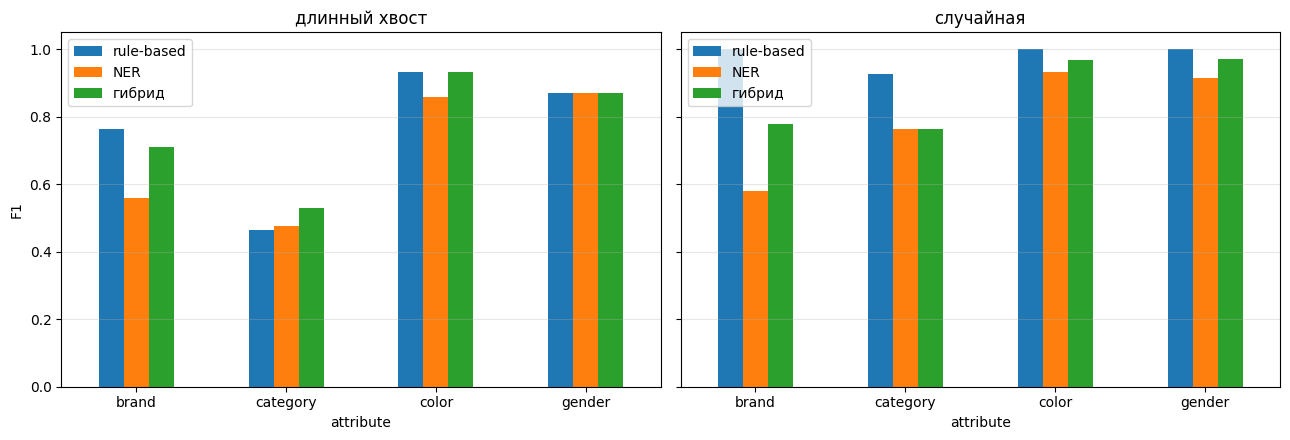

In [14]:
fig_data = pd.concat(
    [tail_f1.assign(sample="длинный хвост"), random_f1.assign(sample="случайная")]
).reset_index()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (sample, group) in zip(axes, fig_data.groupby("sample")):
    group.set_index("attribute")[["rule-based", "NER", "гибрид"]].plot(kind="bar", ax=ax, rot=0)
    ax.set_title(sample)
    ax.set_ylabel("F1")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Главный результат ноутбука.

**На длинном хвосте гибрид работает.** F1 по категории 0.464 → 0.530, то есть
NER действительно закрывает часть пробелов словаря. Это ровно та задача, ради
которой он обучался.

**На случайной выборке гибрид всё ломает.** Brand 1.000 → 0.778,
category 0.928 → 0.763, gender 1.000 → 0.971. Причина в асимметрии: словарь на
своём покрытии почти не ошибается, а NER подставляет значения там, где словарь
честно молчал, потому что атрибута в запросе нет. Каждое такое срабатывание —
чистый false positive.

**NER сам по себе слабее словарей везде**, кроме категории на хвосте (0.477
против 0.464) — и там разница в пределах шума на 100 примерах.

Вывод, который отсюда следует: гибрид в текущем виде нельзя включать глобально.
Его имеет смысл применять выборочно — только к запросам, где словарь не дал
вообще ничего, и только к атрибуту «категория». Разбор ниже показывает, почему.

## Разбор: где NER помогает, а где нет

Смотрю не на агрегат, а на конкретные запросы: в скольких случаях NER заполнил
пропуск словаря верно, в скольких — неверно, и что он ломает.

In [15]:
rows = []
for query, truth in zip(tail_queries, tail_truth):
    rb = {k: v for k, v in extract_all(query).items() if k in ATTRS}
    ner = ner_extract(query)

    for attr in COMPARABLE:
        gold = canonize(attr, truth.get(attr))
        rb_value = canonize(attr, rb.get(attr))
        ner_value = canonize(attr, ner.get(attr))

        if rb_value is not None:
            continue                      # интересны только пропуски словаря
        if gold is None and ner_value is None:
            continue

        if gold is not None and ner_value == gold:
            outcome = "NER закрыл пропуск верно"
        elif gold is not None and ner_value is None:
            outcome = "пропуск остался"
        elif gold is None and ner_value is not None:
            outcome = "NER добавил ложное значение"
        else:
            outcome = "NER ответил неверно"

        rows.append({"query": query, "attribute": attr, "gold": gold,
                     "ner": ner_value, "outcome": outcome})

gap_df = pd.DataFrame(rows)
print(gap_df["outcome"].value_counts().to_string())
print()
print(gap_df[gap_df["outcome"] == "NER закрыл пропуск верно"].head(10).to_string(index=False))

outcome
пропуск остался                39
NER закрыл пропуск верно       12
NER ответил неверно            10
NER добавил ложное значение     9
                            query attribute      gold       ner                  outcome
                     униформа 18+  category  униформа  униформа NER закрыл пропуск верно
                 маска для уоллес  category     маска     маска NER закрыл пропуск верно
агроткань застилочная для дорожка  category агроткань агроткань NER закрыл пропуск верно
                   защита колонок  category   колонок   колонок NER закрыл пропуск верно
                  тахта на ножках  category     тахта     тахта NER закрыл пропуск верно
       красивые постеры в комнату  category   постеры   постеры NER закрыл пропуск верно
         вешалки детские набор 20  category   вешалки   вешалки NER закрыл пропуск верно
               сигнализация ягуар     brand     ягуар     ягуар NER закрыл пропуск верно
        звезда на питбайк 43 зуба  category    звезда  

Из 70 разобранных случаев NER высказался в 31, и лишь в 12 — верно. То есть
точность закрытия пропусков около 39%: на каждое найденное значение приходится
полтора ошибочных.

Ошибки распадаются на два понятных класса.

**Выбор не того слова в качестве категории.** «Набор ключей и головок» →
`головок` вместо `набор`, «сетка рабица металлическая» → `рабица` вместо
`сетка`, «пуфик с ящиком для хранения деревянный» → `деревянный`. Модель хватает
редкое или последнее существительное вместо главного. Это следствие того, что
в обучающих примерах категория чаще стоит первой — на 1400 примерах модель
выучила позиционную эвристику, а не синтаксическую роль.

**Придумывание брендов.** «Ночник ясмина» → бренд `ясмина`, «жилет сириус
европа» → `сириус`, «футболка дантист» → `дантист`. Любое незнакомое слово рядом
с категорией модель склонна пометить как бренд. Это прямое следствие того, что
BRAND в обучении представлен 250 примерами на открытое множество из тысяч
брендов.


In [16]:
print(gap_df[gap_df["outcome"].isin(["NER ответил неверно", "NER добавил ложное значение"])]
      .head(15).to_string(index=False))

                                 query attribute         gold          ner                     outcome
               герметик для террариума  category         None   террариума NER добавил ложное значение
                    atomic heart dlc 3     brand         None atomic heart NER добавил ложное значение
      лубрикант с охлаждающим эффектом     brand         None    лубрикант NER добавил ложное значение
                набор ключей и головок  category        набор      головок         NER ответил неверно
                листья эвкалипта декор     brand         None    эвкалипта NER добавил ложное значение
             обработка травы от клещей  category         None        травы NER добавил ложное значение
пуфик с ящиком для хранения деревянный  category        пуфик   деревянный         NER ответил неверно
                      футболка дантист     brand         None      дантист NER добавил ложное значение
   гигиенический лосьон для ушей кошек  category       лосьон        коше

## Порог уверенности

Порог управляет тем, насколько охотно NER заполняет пропуски. Низкий — больше
закрытых пропусков и больше ложных значений, высокий — наоборот. Оптимум зависит
от того, что дороже для потребителя атрибутов; смотрю на кривую, а не беру
значение по умолчанию.


In [17]:
rows = []
for threshold in (0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
    preds = [hybrid_extract(q, threshold) for q in tail_queries]
    counts, _ = score_extraction(tail_queries, preds, tail_truth)
    table = metrics_table(counts, tail_truth)
    weights = table["support"].where(table["support"] > 0, 0)
    rows.append({
        "threshold": threshold,
        "f1_category": table.loc[table.attribute == "category", "f1"].item(),
        "f1_weighted": float((table["f1"] * weights).sum() / max(weights.sum(), 1)),
    })

print(pd.DataFrame(rows).round(3).to_string(index=False))

 threshold  f1_category  f1_weighted
       0.3        0.533        0.559
       0.4        0.533        0.559
       0.5        0.530        0.546
       0.6        0.551        0.559
       0.7        0.556        0.559
       0.8        0.556        0.562
       0.9        0.562        0.574

Порог ведёт себя монотонно: чем выше, тем лучше. От 0.3 к 0.9 F1 по категории
растёт с 0.533 до 0.562. Это ещё одно подтверждение диагноза — уверенные
предсказания модели полезны, неуверенные добавляют шум. Дефолтные 0.5 здесь
хуже, чем 0.9.

При этом даже на пороге 0.9 гибрид по категории (0.562) заметно выше чистого
словаря на этой выборке (0.464). То есть польза есть, но снимать её нужно
консервативно.

## Итог

Что построено: словарный слой с валидацией на ручной разметке, разметка длинного
хвоста через LLM с проверкой качества самой разметки, NER-энкодер поверх, гибрид
с приоритетом словарей и сравнение трёх подходов на двух разных по составу
выборках.

**Гибрид даёт прирост только на длинном хвосте и только по категории.**
F1 0.464 → 0.530, а при пороге 0.9 — до 0.562. На случайной выборке он портит
всё, что словарь и так делал хорошо. Правильное применение — не глобальное
включение, а срабатывание только на запросах, где словарь вернул пустоту.

**Словари сильнее NER там, где они вообще срабатывают** — 1.00 против 0.58 по
бренду на случайной выборке. Это ожидаемо: словарь на своём покрытии есть
точное правило, а модель на 1400 примерах — приближение. Смысл NER не в том,
чтобы обыграть словари, а в том, чтобы закрывать их пропуски.

**Точность закрытия пропусков — 39%.** Из 31 высказывания NER верны 12. Пока
это соотношение не улучшится, глобальное включение гибрида будет ухудшать
результат.

**Размер обучающей выборки — главное ограничение.** 694 примера от LLM на пять
типов сущностей с открытыми множествами категорий и брендов — мало. Обе
диагностированные ошибки (позиционная эвристика вместо синтаксической роли,
разметка незнакомых слов как брендов) — это признаки недостатка данных, а не
неверной архитектуры.

**Оценки на 100-150 примерах шумные.** Разница в несколько процентных пунктов
между подходами на таком объёме не значима — это видно по доверительным
интервалам в первом ноутбуке.

Что делать дальше по приоритету:

1. Довести LLM-разметку до 3000-5000 примеров, целясь в категории и бренды из
   хвоста. Это самый прямой путь к росту качества NER.
2. Включать NER только там, где словарь не нашёл ничего, и только для категории
   — по текущим данным это единственный режим, который не вредит.
3. Валидировать разметку выборочно вручную и считать согласие: сейчас её
   качество проверено только сверкой со словарями, где они пересекаются.
4. Расширять словари параллельно: для частых категорий это дешевле и точнее
   любой модели.